# Decision Trees
### Imports

In [303]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


#### Load and check data

In [304]:
# Load the training and test data
X_train = pd.read_csv('Datasets/alternative_X_train.csv')
X_test = pd.read_csv('Datasets/alternative_X_test.csv')
y_train = pd.read_csv('Datasets/y_train.csv')
y_test = pd.read_csv('Datasets/y_test.csv')


In [305]:
# Ensure the test data has the same columns as the training data
X_test = X_test[X_train.columns]
y_test = y_test[y_train.columns] 

In [306]:
# check the shape of the data
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# check collumn names are identical
print("X_train columns:", X_train.columns.tolist())
print("X_test columns:", X_test.columns.tolist())

y_train = y_train.values.squeeze()  # Flatten if a single column DataFrame
y_test = y_test.values.squeeze()    

print(y_train)


Shape of X_train: (404, 217)
Shape of y_train: (404, 10)
Shape of y_test: (101, 10)
X_train columns: ['IMDb rating', 'duration', 'content rating', 'year', 'month', 'genre 1', 'genre 2', 'genre 3', 'writer 1', 'writer 2', 'writer 3', 'star 1', 'star 2', 'star 3', 'director 1', 'director 2', 'director 3', 'title_tfidf_1', 'title_tfidf_2', 'title_tfidf_3', 'title_tfidf_4', 'title_tfidf_5', 'title_tfidf_6', 'title_tfidf_7', 'title_tfidf_8', 'title_tfidf_9', 'title_tfidf_10', 'title_tfidf_11', 'title_tfidf_12', 'title_tfidf_13', 'title_tfidf_14', 'title_tfidf_15', 'title_tfidf_16', 'title_tfidf_17', 'title_tfidf_18', 'title_tfidf_19', 'title_tfidf_20', 'title_tfidf_21', 'title_tfidf_22', 'title_tfidf_23', 'title_tfidf_24', 'title_tfidf_25', 'title_tfidf_26', 'title_tfidf_27', 'title_tfidf_28', 'title_tfidf_29', 'title_tfidf_30', 'title_tfidf_31', 'title_tfidf_32', 'title_tfidf_33', 'title_tfidf_34', 'title_tfidf_35', 'title_tfidf_36', 'title_tfidf_37', 'title_tfidf_38', 'title_tfidf_39', 't

In [307]:
# check if there are missing values or collumns
train_columns = set(X_train.columns)
test_columns = set(X_test.columns)

missing_in_test = train_columns - test_columns
extra_in_test = test_columns - train_columns

print("Missing in X_test:", missing_in_test)
print("Extra in X_test:", extra_in_test)


Missing in X_test: set()
Extra in X_test: set()


## Initialize and train the decision tree

In [308]:
# Initialize the classifier
dt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=60) # choose entropy as the data set is smaller

# Train the classifier
dt_classifier.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=60)

## Predict

In [309]:
# Predict on test data
y_pred = dt_classifier.predict(X_test)

In [310]:
# Check if the shapes of y_test and y_pred match
print("Shape of y_test:", y_test.shape)
print("Shape of y_pred:", y_pred.shape)
assert y_test.shape == y_pred.shape, "Shapes of y_test and y_pred must match."


Shape of y_test: (101, 10)
Shape of y_pred: (101, 10)


## Evaluate model

In [311]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.09
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00        11
           2       0.08      0.06      0.07        16
           3       0.16      0.20      0.18        15
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00         7
           6       0.15      0.24      0.18        17
           7       0.00      0.00      0.00        12
           8       0.25      0.33      0.29        18
           9       0.22      0.36      0.28        11

   micro avg       0.15      0.14      0.15       126
   macro avg       0.09      0.12      0.10       126
weighted avg       0.10      0.14      0.12       126
 samples avg       0.16      0.15      0.15       126



## Visualize tree

In [312]:
tree_rules = export_text(dt_classifier, feature_names=list(X_train.columns))
print(tree_rules)


|--- year <= 1966.50
|   |--- IMDb rating <= 0.74
|   |   |--- star 3 <= 24.00
|   |   |   |--- writer 3 <= 60.00
|   |   |   |   |--- class: 0
|   |   |   |--- writer 3 >  60.00
|   |   |   |   |--- title_tfidf_81 <= 0.33
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- title_tfidf_81 >  0.33
|   |   |   |   |   |--- class: 0
|   |   |--- star 3 >  24.00
|   |   |   |--- IMDb description_tfidf_3 <= 0.36
|   |   |   |   |--- IMDb description_tfidf_57 <= 0.30
|   |   |   |   |   |--- IMDb description_tfidf_100 <= 0.22
|   |   |   |   |   |   |--- IMDb description_tfidf_29 <= 0.28
|   |   |   |   |   |   |   |--- star 3 <= 64.50
|   |   |   |   |   |   |   |   |--- year <= 1962.50
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- year >  1962.50
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- star 3 >  64.50
|   |   |   |   |   |   |   |   |--- month <= 3.50
|   |   |   |   |   |   |   |   |   |--- class: 0
|  

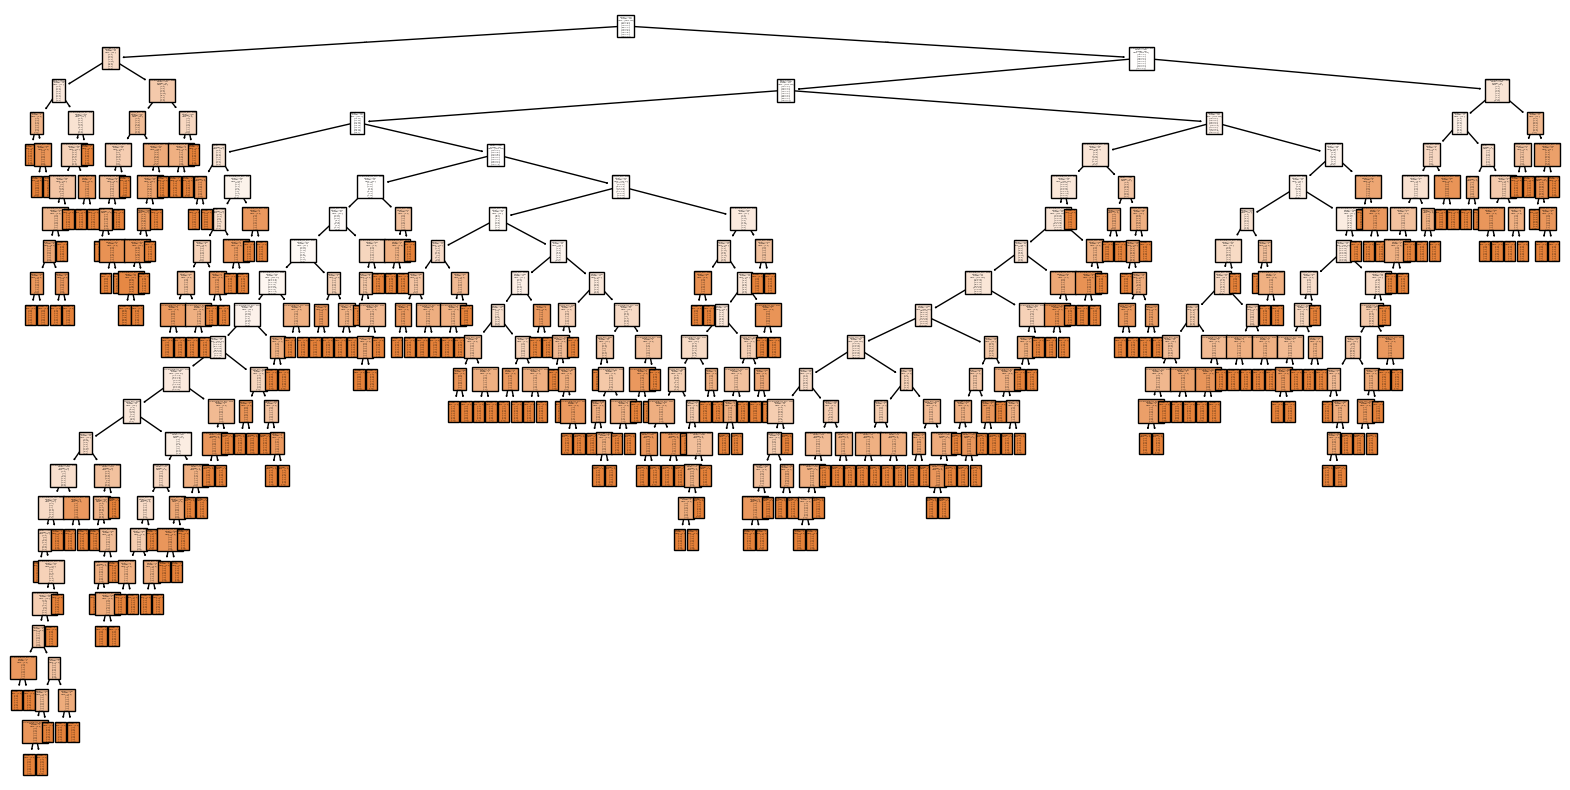

In [313]:
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, feature_names=X_train.columns, class_names=dt_classifier.classes_, filled=True)
plt.show()


## Optimize training/Finetuning the decision tree

**Hyperparameter Tuning**: Use techniques like grid search (GridSearchCV) or random search (RandomizedSearchCV) to find optimal parameters for your decision tree. 

**Overfitting Prevention**: Adjust parameters like max_depth, min_samples_split, and min_samples_leaf to prevent overfitting.


### Gridsearch

In [314]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [1, 5, 4],
    'min_samples_leaf': [1, 3, 4],
    'criterion': ['gini', 'entropy']
}


In [315]:
# Initialize the model
dt_classifier = DecisionTreeClassifier(random_state=33)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=1; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=1; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=1; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=1; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=1; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1

/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 436, in _validate_par

In [316]:
# Use the best hyperparameters to initialize a new model
best_dt_classifier = DecisionTreeClassifier(**best_params, random_state=42)

# Fit the model on the training data
best_dt_classifier.fit(X_train, y_train)

# Evaluate on the test data
y_pred = best_dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Test Set Accuracy: 0.07
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.50      0.09      0.15        11
           2       0.00      0.00      0.00        16
           3       0.09      0.27      0.14        15
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00         7
           6       0.27      0.18      0.21        17
           7       0.20      0.08      0.12        12
           8       0.25      0.17      0.20        18
           9       0.00      0.00      0.00        11

   micro avg       0.14      0.10      0.11       126
   macro avg       0.13      0.08      0.08       126
weighted avg       0.15      0.10      0.10       126
 samples avg       0.12      0.09      0.10       126



/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Randomized Search

In [317]:
# Randomized parameter grid
random_grid = {
    'max_depth': [None] + list(np.arange(3, 15)),
    'min_samples_split': np.arange(2, 10),
    'min_samples_leaf': np.arange(1, 5),
    'criterion': ['gini', 'entropy']
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=dt_classifier, param_distributions=random_grid, n_iter=50, cv=5, scoring='accuracy', verbose=2, random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV to the data
random_search.fit(X_train, y_train)

# Get the best parameters
best_params = random_search.best_params_
print("\n Best Hyperparameters:", best_params)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=8, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END criterion=entropy, max_depth=14, min_samples_leaf=3, min_samples_split=5; total time=   0.0s
[CV] END criterion=entropy, max_depth=14, min_samples_leaf=3, min_samples_split=5; total time=   0.0s
[CV] END criterion=entropy, max_depth=14, min_samples_leaf=3, min_samples_split=5; total time=   0.0s
[CV] END criterion=entropy, max_depth=14, min_samples_leaf=3, min_samples_split=5; total time=   0.0s
[CV] END criterion=entrop

In [318]:
# Use the best hyperparameters to initialize a new model
best_dt_classifier = DecisionTreeClassifier(**best_params, random_state=42)

# Fit the model on the training data
best_dt_classifier.fit(X_train, y_train)

# Evaluate on the test data
y_pred = best_dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Test Set Accuracy: 0.12
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00        11
           2       0.14      0.06      0.09        16
           3       0.18      0.20      0.19        15
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00         7
           6       0.17      0.29      0.22        17
           7       0.00      0.00      0.00        12
           8       0.28      0.39      0.33        18
           9       0.27      0.55      0.36        11

   micro avg       0.19      0.17      0.18       126
   macro avg       0.10      0.15      0.12       126
weighted avg       0.13      0.17      0.14       126
 samples avg       0.19      0.19      0.18       126



/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/reneehagemans/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
